# 在 Colab 中打开
<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ai-agents-the-definitive-guide/blob/main/CH02/ch02_ToT.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# 关于这个 Notebook

这个 Notebook 演示一个小型但完整的 multi-agent writing workflow（多智能体写作工作流）：它先规划，再研究，最后起草一篇面向开发者的博客文章。整个流程把 structured outputs（结构化输出）、tool-using research（工具辅助研究）和带 checkpoint（检查点）的简单 LangGraph pipeline（流水线）组合在一起。

## 它展示了什么

* **一个四阶段图（four-stage graph）**

  1. **propose**：通过结构化输出生成三个有创意的候选方案
  2. **reflect**：使用更强的 judge（评审模型）批判性比较并选出最佳方案
  3. **research**：使用 SerpAPI 搜索收集资料，并综合为 JSON
  4. **draft**：基于选中的方案生成最终大纲和引言
* **角色与模型分离**

  * 一个小型创意生成器
  * 一个更严格的评审模型
  * 一个绑定工具的研究员
  * 一个用于最终起草的小型写作模型
* **Typed state（类型化状态）**：保存累积消息、候选方案与选择结果 JSON、综合后的资料，以及最终草稿
* **In-memory checkpoints（内存检查点）**：通过 `MemorySaver` 保存
* **可读的 streaming trace（流式执行轨迹）**：运行时打印每个节点的更新
* **图预览**：通过 Mermaid PNG 展示

## 你将运行什么

1. 从 `.env` 加载 `OPENAI_API_KEY` 和 `SERPAPI_API_KEY`。
2. 定义 `internet_search` 工具，让它通过 SerpAPI 返回紧凑的 JSON 搜索结果。
3. 为候选方案、选择结果和搜索查询建立 Pydantic schema（模式），保证输出结构化。
4. 串联一个包含四个节点的 **线性 LangGraph**，并使用 checkpointer（检查点保存器）完成编译。
5. 用一个主题 Prompt 启动运行，并观察系统从每个节点流式输出更新。
6. 检查最终草稿并渲染图结构。

## 它如何工作

* **提出候选方案（Propose options）**：使用 `with_structured_output(OptionsPayload)` 强制生成三个字段一致的候选方案。
* **反思并选择（Reflect and select）**：使用更强的模型和 `ChoicePayload`，按索引选择最佳方案并给出理由。代码还会防御性地限制索引范围。
* **使用工具研究（Research with tools）**

  * 研究员先通过结构化 schema 提出 3～5 个精确查询
  * Notebook 对每个查询调用 `internet_search`，收集原始发现
  * 一个紧凑的综合步骤把搜索结果整理成干净的 `sources_json`，并附带建议引用
* **起草大纲与引言（Draft outline and intro）**：把选中的方案和资料转换为标题、受众说明、五部分大纲以及一段简短引言。

## 为什么采用这种模式

* 清晰的 role separation（角色分离）能提高质量和透明度。生成、评估、研究和写作由不同 Prompt，甚至不同模型负责。
* Structured outputs（结构化输出）减少歧义，让 routing（路由）更直接。
* 工具调用是显式且可观察的，因此整个过程更容易审计。
* LangGraph 让控制流保持清晰，同时几乎不增加样板代码就能提供 thread-scoped memory（线程范围内存）。

## 如何扩展与调整

* 把 SerpAPI 替换为你偏好的搜索服务，或加入文档仓库检索工具。
* 在研究和起草之间增加 factuality checker（事实性检查器）或 citation verifier（引用验证器）。
* 把 checkpoint 持久化到数据库，以支持长时间运行的项目。
* 增加最终 formatter node（格式化节点），把草稿转换成 Markdown 或 HTML。

## 运行要求与说明

* 必须提供 `OPENAI_API_KEY`；实时搜索还需要 `SERPAPI_API_KEY`。
* 互联网搜索结果会随时间变化，因此不同运行得到的来源可能不同。
* 创意模型设置了略高的 temperature（温度）；评审模型的温度接近 0，以提高稳定性。
* 多阶段流式执行会累计 Token 和 API 成本。

## 适合谁

适合希望获得实用模板的工程师、技术写作者和研究人员：用一个小型、角色分工明确的 writing agent（写作智能体），在简单 LangGraph 工作流中组合结构化规划、工具辅助研究和内容起草。


# 依赖项

In [1]:
!pip install -q langchain==0.3.27 \
                langgraph==0.6.7 \
                langchain-openai==0.3.32 \
                langchain_experimental==0.3.4 \
                langchain_community==0.3.29 \
                python-dotenv==1.0.1 \
                langchain-core==0.3.75 \
                serpapi==0.1.5 \
                google-search-results==2.4.2

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.0/444.0 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that

# API 配置

In [2]:
# --- API Key Setup ---
# Option 1 (preferred): create a `.env` file in your project folder with:
# OPENAI_API_KEY=your_openai_key_here
# SERPAPI_API_KEY=your_serpapi_key_here
#
# Option 2: set it directly in the notebook with magic:
# %env OPENAI_API_KEY=your_openai_key_here
# %env SERPAPI_API_KEY=your_serpapi_key_here

from dotenv import load_dotenv
import os

# Load from .env if available
load_dotenv()

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
serp_api_key = os.getenv("SERPAPI_API_KEY")

# Fallback: ask if still missing
if not OPENAI_API_KEY:
    print("⚠️ OPENAI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    OPENAI_API_KEY = input("Enter your OPENAI_API_KEY: ").strip()

if not serp_api_key:
    print("⚠️ SERPAPI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    serp_api_key = input("Enter your SERPAPI_API_KEY: ").strip()

print("✅ API keys loaded successfully!")



✅ API keys loaded successfully!


# 导入依赖

In [3]:
import os, json, uuid
from typing import Annotated, List, TypedDict

from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, ToolMessage
from langchain_core.tools import tool
from serpapi import GoogleSearch

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

# 工具：`internet_search`

In [4]:
@tool("internet_search")
def internet_search(query: str) -> str:
    """Search Google via SerpAPI for up to date information. Returns compact JSON."""
    key = os.getenv("SERPAPI_API_KEY")
    if not key:
        return "[]"
    params = {"engine": "google", "q": query, "api_key": key, "num": 5, "hl": "en", "gl": "us"}
    data = GoogleSearch(params).get_dict()
    out = []
    for r in (data.get("organic_results") or [])[:5]:
        out.append({
            "title": r.get("title"),
            "link": r.get("link"),
            "snippet": r.get("snippet"),
            "source": r.get("source"),
        })
    return json.dumps(out, ensure_ascii=False)

tools = [internet_search]

# 模型：小型生成器、更强的评审模型、绑定工具的研究模型

In [5]:
gen_llm       = ChatOpenAI(model="gpt-5.4-nano", temperature=0.7)   # creative, cheaper
judge_llm     = ChatOpenAI(model="gpt-5.4",      temperature=0.2)   # stricter judge
research_llm  = ChatOpenAI(model="gpt-5.4-nano", temperature=0.2).bind_tools(tools, tool_choice="auto")
writer_llm    = gen_llm  # reuse small model for drafting



# 结构化 payload（Pydantic v2）

In [6]:
class Option(BaseModel):
    title: str
    audience: str
    angle: str
    outline: List[str] = Field(min_items=5, max_items=5)
    rationale: str

class OptionsPayload(BaseModel):
    options: List[Option] = Field(min_items=3, max_items=3)

class ChoicePayload(BaseModel):
    choice_index: int = Field(ge=0, le=2)
    rationale: str

class Queries(BaseModel):
    queries: List[str] = Field(min_items=3, max_items=5)


/tmp/ipykernel_878/82148009.py:5: PydanticDeprecatedSince20: `min_items` is deprecated and will be removed, use `min_length` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  outline: List[str] = Field(min_items=5, max_items=5)
/tmp/ipykernel_878/82148009.py:5: PydanticDeprecatedSince20: `max_items` is deprecated and will be removed, use `max_length` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  outline: List[str] = Field(min_items=5, max_items=5)
/tmp/ipykernel_878/82148009.py:9: PydanticDeprecatedSince20: `min_items` is deprecated and will be removed, use `min_length` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  options: List[Option] = Field(min_items=3, max_items=3)
/tmp/ipykernel_878/82148009.py:9: Pydant

# State（状态）

In [7]:
class BlogState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    topic: str
    options_json: str | None
    choice_json: str | None
    sources_json: str | None
    draft: str | None

# Nodes（节点）

In [8]:

def propose_options(state: BlogState) -> BlogState:
    """Generator (small): propose 3 creative approaches (ToT-style branching)."""
    proposer = gen_llm.with_structured_output(OptionsPayload)
    prompt = (
        "Generate exactly 3 distinct approaches for a developer-focused blog on:\n"
        f"{state['topic']}\n\nFor each option, provide: title, audience, angle, "
        "a 5-bullet outline, and a concise rationale."
    )
    payload: OptionsPayload = proposer.invoke(prompt)
    state["options_json"] = payload.model_dump_json()
    state["messages"].append(AIMessage(content=state["options_json"]))
    return state

def reflect_and_select(state: BlogState) -> BlogState:
    """Judge (stronger): critique options and select best one."""
    chooser = judge_llm.with_structured_output(ChoicePayload)
    eval_prompt = (
        "Evaluate the 3 approaches for clarity, originality, developer relevance, "
        "and feasibility under time constraints. Pick ONE by index 0..2 and justify.\n\n"
        f"Options JSON:\n{state['options_json']}"
    )
    choice: ChoicePayload = chooser.invoke(eval_prompt)
    # Defensive clamp
    opts = json.loads(state["options_json"])["options"]
    idx = max(0, min(choice.choice_index, len(opts)-1))
    choice.choice_index = idx
    state["choice_json"] = choice.model_dump_json()
    state["messages"].append(AIMessage(content=state["choice_json"]))
    return state

def research_with_tools(state: BlogState) -> BlogState:
    """Researcher (tool-using): propose queries, call search tool(s), synthesize sources JSON."""
    # 1) Ask for tight queries (structured)
    q_llm = research_llm.with_structured_output(Queries)
    q_payload: Queries = q_llm.invoke(
        "Propose 3–5 precise web queries (docs/repos/papers/blog posts) to support the chosen approach.\n"
        f"Topic: {state['topic']}\nOptions: {state['options_json']}\nChoice: {state['choice_json']}"
    )

    # 2) Call tool(s) explicitly (deterministic, observable)
    findings = []
    for q in q_payload.queries:
        res = internet_search.invoke({"query": q})
        try:
            findings.append({"query": q, "results": json.loads(res)})
        except Exception:
            findings.append({"query": q, "results": []})

    # 3) Synthesize to a clean JSON list of sources
    synth_prompt = (
        "From these search findings, produce JSON list 'sources': "
        "[{query, top_findings: [3-5 bullets], suggested_citations: [{title, url}]}]. "
        "Return JSON only."
    )
    synth = research_llm.invoke([
        ("system", "Return JSON only."),
        HumanMessage(content=json.dumps(findings, ensure_ascii=False))
    ])
    state["sources_json"] = synth.content
    state["messages"].append(AIMessage(content=state["sources_json"]))
    return state

def draft_outline_and_intro(state: BlogState) -> BlogState:
    """Writer (small): outline + intro from chosen plan and sources."""
    system = (
        "You are a senior technical writer. Using the chosen approach and sources, produce:\n"
        "1) Final title\n2) Audience sentence\n3) 5-section outline (2–3 bullets each)\n"
        "4) 150–200 word intro. Be clear, concrete, and avoid hype."
    )
    ai = writer_llm.invoke([
        ("system", system),
        HumanMessage(content=f"Choice:\n{state['choice_json']}\n\nSources:\n{state['sources_json']}")
    ])
    state["draft"] = ai.content
    state["messages"].append(ai)
    return state

# 图结构连接（Graph wiring）

In [9]:
graph = StateGraph(BlogState)
graph.add_node("propose", propose_options)        # small creative generator
graph.add_node("reflect", reflect_and_select)     # stronger judge/reflector
graph.add_node("research", research_with_tools)   # tool-using researcher
graph.add_node("draft", draft_outline_and_intro)  # small writer

graph.add_edge(START, "propose")
graph.add_edge("propose", "reflect")
graph.add_edge("reflect", "research")
graph.add_edge("research", "draft")
graph.add_edge("draft", END)

checkpointer = MemorySaver()
app = graph.compile(checkpointer=checkpointer)

# 运行

In [10]:
cfg = {"configurable": {"thread_id": f"blog-{uuid.uuid4()}"}, "recursion_limit": 40}
initial: BlogState = {
    "messages": [HumanMessage(content="Plan a blog post about AI agents for developers.")],
    "topic": "AI Agents for Developers: From LLMs to Tool-Using Systems",
    "options_json": None,
    "choice_json": None,
    "sources_json": None,
    "draft": None,
}

for update in app.stream(initial, config=cfg, stream_mode="updates"):
    for node, payload in update.items():
        print(f"\n[enter {node}] keys: {list(payload.keys())}")
        if "messages" in payload and payload["messages"]:
            m = payload["messages"][-1]
            text = getattr(m, "content", "")
            print((text if isinstance(text, str) else str(text))[:400], "...")

final = app.get_state(cfg).values
print("\n===== FINAL DRAFT =====\n")
print((final.get("draft") or ""))



[enter propose] keys: ['messages', 'topic', 'options_json', 'choice_json', 'sources_json', 'draft']
{"options":[{"title":"Harnessing LLMs: Building Intelligent AI Agents for Development","audience":"Software developers and AI enthusiasts","angle":"Practical guide to implementing LLMs in AI agents for development tasks","outline":["Introduction to LLMs and their capabilities","Overview of AI agents and their roles in development","Step-by-step guide to integrating LLMs into development workflows" ...

[enter reflect] keys: ['messages', 'topic', 'options_json', 'choice_json', 'sources_json', 'draft']
{"choice_index":0,"rationale":"The chosen approach, \"Harnessing LLMs: Building Intelligent AI Agents for Development,\" stands out for several reasons:\n\n1. **Clarity**: \n   - The approach is structured as a practical guide, making it clear and accessible for its intended audience of software developers and AI enthusiasts. The step-by-step guide ensures that readers can follow along easi

# 显示图结构

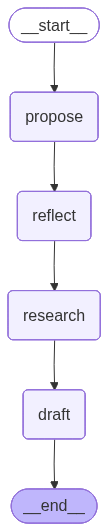

In [11]:

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))